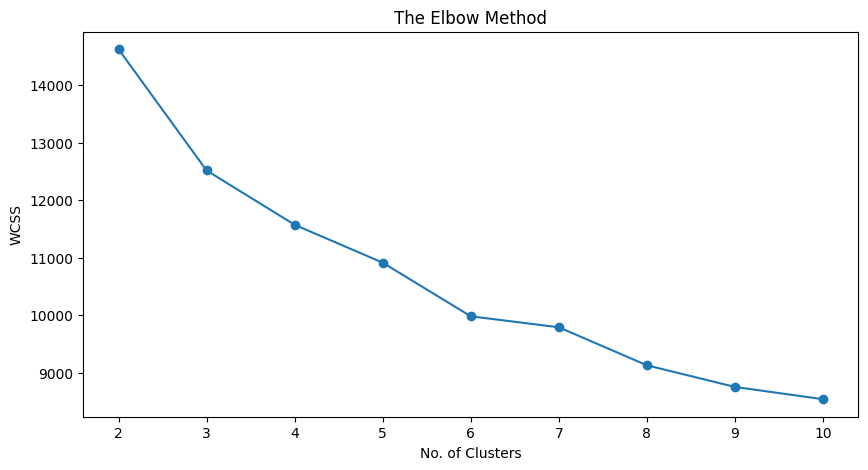

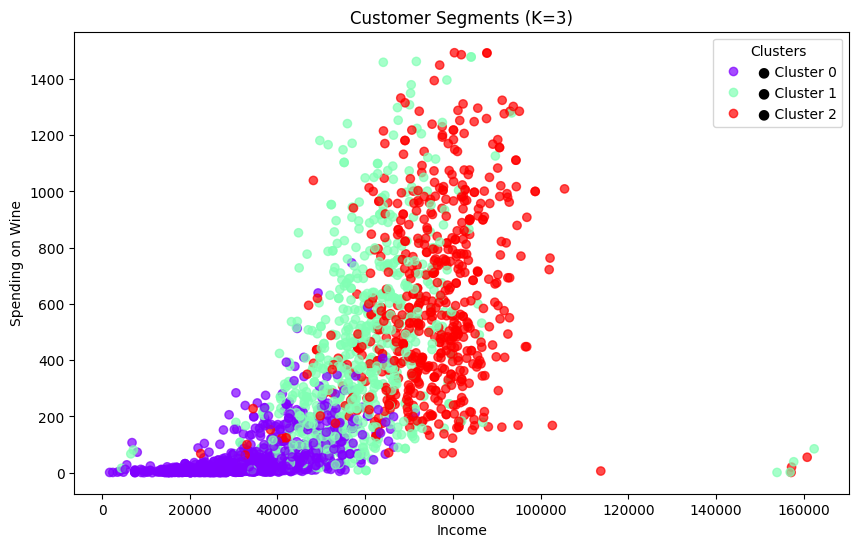

     ID  Cluster
0  5524        2
1  2174        0
2  4141        2
3  6182        0
4  5324        0


In [55]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as mtp
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('marketing_campaign.csv', sep='\t')
df = df.dropna(subset=['Income'])
df = df[df['Income'] < 600000]

features = ['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits',
            'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_subset = df[features]
df_subset = df_subset.fillna(df_subset.median())
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_subset)
wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)
mtp.figure(figsize=(10, 5))
mtp.plot(range(2, 11), wcss, marker='o')
mtp.title('The Elbow Method')
mtp.xlabel('No. of Clusters')
mtp.ylabel('WCSS')
mtp.show()
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(x_scaled)

mtp.figure(figsize=(10, 6))
scatter = mtp.scatter(df['Income'], df['MntWines'], c=df['Cluster'], cmap='rainbow', alpha=0.7)
handles, labels = scatter.legend_elements()
legend_labels = [f"● Cluster {i}" for i in range(k_optimal)]
mtp.legend(handles, legend_labels, title="Clusters")
mtp.title(f'Customer Segments (K={k_optimal})')
mtp.xlabel('Income')
mtp.ylabel('Spending on Wine')
mtp.show()
print(df[['ID', 'Cluster']].head())

In [56]:
!pip install ortools